In [94]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/masou

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import CategoricalCrossentropy

In [96]:
train_path = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
test_path = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'

IMG_SIZE = (224,224)   # Increased resolution
BATCH_SIZE = 32

In [97]:




# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=40,       # Significant increase
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.2,
#     zoom_range=0.3,          # More zoom to focus on tumor variants
#     horizontal_flip=True,
#     vertical_flip=True,      # Non-negotiable for MRI
#     fill_mode='reflect',     # 'reflect' creates more realistic MRI edges than 'nearest'
#     validation_split=0.2
# )




# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=30,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.2,
#     zoom_range=0.3,
#     horizontal_flip=True,
#     vertical_flip=True,
#     brightness_range=[0.7, 1.3],    # Simulate different MRI contrast levels
#     channel_shift_range=20.0,       # Randomly shift color intensities
#     fill_mode='reflect',
#     validation_split=0.2
# )




train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,      # Essential for MRI spatial invariance
    brightness_range=[0.8, 1.2], # Handle different scanner exposures
    fill_mode='reflect',     # 'reflect' is superior to 'nearest' for medical edges
    validation_split=0.2
)






test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [98]:
from sklearn.utils.class_weight import compute_class_weight

class_labels = list(train_generator.class_indices.keys())
y_train = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


In [99]:
# def custom_weighted_loss(class_weights):
#     weights = tf.constant(list(class_weights.values()), dtype=tf.float32)

#     def loss(y_true, y_pred):
#         y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
#         loss = -tf.reduce_sum(y_true * tf.math.log(y_pred) * weights, axis=1)
#         return tf.reduce_mean(loss)

#     return loss



import tensorflow as tf

def custom_weighted_loss_with_smoothing(class_weights, smoothing=0.1):
    # Convert dictionary weights to a tensor
    weights = tf.constant(list(class_weights.values()), dtype=tf.float32)

    def loss(y_true, y_pred):
        # 1. Apply Label Smoothing manually
        num_classes = tf.cast(tf.shape(y_true)[1], tf.float32)
        y_true_smoothed = y_true * (1.0 - smoothing) + (smoothing / num_classes)
        
        # 2. Prevent log(0) exploding gradients
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        
        # 3. Apply the mathematical gradient penalty (w_i)
        loss_val = -tf.reduce_sum(y_true_smoothed * tf.math.log(y_pred) * weights, axis=1)
        
        return tf.reduce_mean(loss_val)

    return loss

In [100]:
# input_layer = Input(shape=(224, 224, 3))

# # ----- Custom CNN Branch -----
# x = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
# x = BatchNormalization()(x)
# x = MaxPooling2D()(x)

# x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
# x = BatchNormalization()(x)
# x = MaxPooling2D()(x)

# x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
# x = BatchNormalization()(x)
# x = MaxPooling2D()(x)

# cnn_branch = GlobalAveragePooling2D()(x)

# # ----- ResNet50 Branch -----
# resnet_base = ResNet50(
#     weights='imagenet',
#     include_top=False,
#     input_tensor=input_layer
# )


# resnet_base.trainable = False  # Phase 1 freeze

# resnet_branch = GlobalAveragePooling2D()(resnet_base.output)

# #----- Fusion -----
# combined = Concatenate()([cnn_branch, resnet_branch])

# x = Dense(256, activation='relu')(combined)
# x = BatchNormalization()(x)
# x = Dropout(0.5)(x)

# output = Dense(len(class_labels), activation='softmax')(x)

# model = Model(inputs=input_layer, outputs=output)






# from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Concatenate, Add, Multiply, Lambda
# from tensorflow.keras.applications import ResNet50
# from tensorflow.keras.models import Model
# import tensorflow.keras.backend as K

# input_layer = Input(shape=(224, 224, 3))

# # ----- Branch 1: Custom CNN Feature Extractor -----
# x = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
# x = BatchNormalization()(x)
# x = MaxPooling2D()(x)

# x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
# x = BatchNormalization()(x)
# x = MaxPooling2D()(x)

# x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
# x = BatchNormalization()(x)
# x = MaxPooling2D()(x)

# cnn_branch = GlobalAveragePooling2D()(x)

# # ----- Branch 2: Pre-trained ResNet50 -----
# resnet_base = ResNet50(weights='imagenet', include_top=False, input_tensor=input_layer)


# resnet_base.trainable = False  # Phase 1 freeze
# resnet_branch = GlobalAveragePooling2D()(resnet_base.output)

# # ----- PROPOSED INNOVATION: Dynamic Adaptive Fusion Mechanism -----
# # 1. Project both branches to the same dense space (e.g., 256) so they can be added/multiplied
# cnn_proj = Dense(256, activation='relu')(cnn_branch)
# resnet_proj = Dense(256, activation='relu')(resnet_branch)

# # 2. Extract the learnable gating parameter (alpha) using Sigmoid
# concat_for_alpha = Concatenate()([cnn_branch, resnet_branch])
# alpha = Dense(256, activation='sigmoid', name='alpha_gate')(concat_for_alpha)

# # 3. Calculate (1 - alpha)
# one_minus_alpha = Lambda(lambda x: 1.0 - x)(alpha)

# # 4. Element-wise mathematical weighting
# weighted_cnn = Multiply()([alpha, cnn_proj])
# weighted_resnet = Multiply()([one_minus_alpha, resnet_proj])

# # 5. Final Fused Vector
# fused_vector = Add()([weighted_cnn, weighted_resnet])

# # ----- Classification Head -----
# x = Dense(256, activation='relu')(fused_vector)
# x = BatchNormalization()(x)
# x = Dropout(0.5)(x)
# output = Dense(len(class_labels), activation='softmax')(x)

# model = Model(inputs=input_layer, outputs=output)




# # Instead of resnet_base.output, let's grab an intermediate layer for better texture detail
# intermediate_layer = resnet_base.get_layer('conv4_block6_out').output 
# resnet_branch = GlobalAveragePooling2D()(intermediate_layer)

# # Re-Fusion
# combined = Concatenate()([cnn_branch, resnet_branch])

# x = Dense(512, activation='relu')(combined) # Increased capacity
# x = BatchNormalization()(x)
# x = Dropout(0.4)(x)
# x = Dense(128, activation='relu')(x) # Extra layer for non-linear reasoning
# x = BatchNormalization()(x)
# output = Dense(len(class_labels), activation='softmax')(x)

# model = Model(inputs=input_layer, outputs=output)





# from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Concatenate
# from tensorflow.keras.applications import ResNet50
# from tensorflow.keras.models import Model

# input_layer = Input(shape=(224, 224, 3))

# # --- Branch 1: Custom CNN (Edge/Texture Focus) ---
# x1 = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
# x1 = BatchNormalization()(x1)
# x1 = MaxPooling2D()(x1)

# x1 = Conv2D(64, (3,3), activation='relu', padding='same')(x1)
# x1 = BatchNormalization()(x1)
# x1 = MaxPooling2D()(x1)

# x1 = Conv2D(128, (3,3), activation='relu', padding='same')(x1)
# x1 = BatchNormalization()(x1)
# x1 = MaxPooling2D()(x1)
# cnn_branch = GlobalAveragePooling2D()(x1) 

# # --- Branch 2: ResNet50 Intermediate (Structural Focus) ---
# # Re-instantiate to ensure it's tied to our specific input_layer
# resnet_base = ResNet50(weights='imagenet', include_top=False, input_tensor=input_layer)
# resnet_base.trainable = False # Start frozen

# # We pull from conv4 to get mid-level features (tumor shapes) 
# # instead of the very abstract final layer.
# intermediate_layer = resnet_base.get_layer('conv4_block6_out').output 
# resnet_branch = GlobalAveragePooling2D()(intermediate_layer)

# # --- The "Senior Researcher" Fusion ---
# combined = Concatenate()([cnn_branch, resnet_branch])

# # We expand capacity to 512 to handle the high-dimensional feature map fusion
# x = Dense(512, activation='relu')(combined) 
# x = BatchNormalization()(x)
# x = Dropout(0.5)(x) # Higher dropout to force general feature learning

# x = Dense(128, activation='relu')(x) # Second reasoning layer
# x = BatchNormalization()(x)

# output = Dense(len(class_labels), activation='softmax')(x)

# model = Model(inputs=input_layer, outputs=output)













# from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Dropout, BatchNormalization, Concatenate
# from tensorflow.keras.applications import ResNet50
# from tensorflow.keras.models import Model

# input_layer = Input(shape=(224, 224, 3))

# # --- Branch 1: Custom CNN (Edge/Texture Focus) ---
# x1 = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
# x1 = BatchNormalization()(x1)
# x1 = MaxPooling2D()(x1)

# x1 = Conv2D(64, (3,3), activation='relu', padding='same')(x1)
# x1 = BatchNormalization()(x1)
# x1 = MaxPooling2D()(x1)

# x1 = Conv2D(128, (3,3), activation='relu', padding='same')(x1)
# x1 = BatchNormalization()(x1)
# x1 = MaxPooling2D()(x1)

# # CHANGE: Using Concatenated Global Average and Max Pooling for CNN branch
# cnn_avg = GlobalAveragePooling2D()(x1)
# cnn_max = GlobalMaxPooling2D()(x1)
# cnn_branch = Concatenate()([cnn_avg, cnn_max])

# # --- Branch 2: ResNet50 Intermediate (Structural Focus) ---
# resnet_base = ResNet50(weights='imagenet', include_top=False, input_tensor=input_layer)
# resnet_base.trainable = False 

# # Extraction from mid-level layer
# intermediate_layer = resnet_base.get_layer('conv4_block6_out').output 

# # CHANGE: Using Concatenated Global Average and Max Pooling for ResNet branch
# resnet_avg = GlobalAveragePooling2D()(intermediate_layer)
# resnet_max = GlobalMaxPooling2D()(intermediate_layer)
# resnet_branch = Concatenate()([resnet_avg, resnet_max])

# # --- The "Senior Researcher" Fusion ---
# # This now merges 4 distinct pooling maps instead of 2
# combined = Concatenate()([cnn_branch, resnet_branch])

# # We expand capacity to handle the richer feature maps
# x = Dense(512, activation='relu')(combined) 
# x = BatchNormalization()(x)
# x = Dropout(0.5)(x) 

# x = Dense(128, activation='relu')(x) 
# x = BatchNormalization()(x)

# output = Dense(len(class_labels), activation='softmax')(x)

# model = Model(inputs=input_layer, outputs=output)








from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

input_layer = Input(shape=(224, 224, 3))

# --- Branch 1: Custom CNN (Low-level texture) ---
x1 = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D()(x1)
x1 = Conv2D(64, (3,3), activation='relu', padding='same')(x1)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D()(x1)

cnn_avg = GlobalAveragePooling2D()(x1)
cnn_max = GlobalMaxPooling2D()(x1)
cnn_branch = Concatenate()([cnn_avg, cnn_max])

# --- Branch 2: ResNet50 Intermediate (Structural logic) ---
resnet_base = ResNet50(weights='imagenet', include_top=False, input_tensor=input_layer)
resnet_base.trainable = False 

# Extracting from conv4 to avoid over-abstraction
intermediate = resnet_base.get_layer('conv4_block6_out').output 
resnet_avg = GlobalAveragePooling2D()(intermediate)
resnet_max = GlobalMaxPooling2D()(intermediate)
resnet_branch = Concatenate()([resnet_avg, resnet_max])

# --- Fusion ---
# combined = Concatenate()([cnn_branch, resnet_branch])

# x = Dense(512, activation='relu')(combined)
# x = BatchNormalization()(x)
# x = Dropout(0.5)(x) 
# x = Dense(128, activation='relu')(x)
# x = BatchNormalization()(x)

# output = Dense(len(class_labels), activation='softmax')(x)
# model = Model(inputs=input_layer, outputs=output)




# --- Update only this part at the end of Cell 7 ---
from tensorflow.keras.regularizers import l2

combined = Concatenate()([cnn_branch, resnet_branch])

# Adding L2 regularization is the key to stopping that loss divergence
x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(combined) 
x = BatchNormalization()(x)
x = Dropout(0.5)(x) 

x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)

output = Dense(len(class_labels), activation='softmax')(x)

In [101]:
# loss_fn = CategoricalCrossentropy(label_smoothing=0.1)


# model.compile(
#     optimizer=Adam(learning_rate=1e-4),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# model.summary()



#from tensorflow.keras.optimizers import Adam

# # Call the custom loss with the weights you defined in Cell 29
# active_loss_function = custom_weighted_loss_with_smoothing(class_weights, smoothing=0.1)

# model.compile(
#     optimizer=Adam(learning_rate=1e-4),
#     loss=active_loss_function,
#     metrics=['accuracy']
# )




#2nd
# Label smoothing helps the model generalize better and reduces overconfidence
# loss_fn = CategoricalCrossentropy(label_smoothing=0.15) 

# model.compile(
#     optimizer=Adam(learning_rate=1e-4),
#     loss=loss_fn, # Use the smoothing loss
#     metrics=['accuracy']
# )

# model.summary()





# We use a slightly higher label smoothing to force the model to 
# learn the 'essence' of the tumor rather than memorizing noise.
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

In [102]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1),
    ModelCheckpoint('best_hybrid_model.h5', monitor='val_accuracy', save_best_only=True)
]


In [103]:
# Stop training when validation loss stops improving to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

# Crucial for 97%+ : Lower LR when learning stalls to find local minima
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=4, 
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_brain_model.keras', 
    monitor='val_accuracy', 
    save_best_only=True
)

# Update your fit call to include these:
# history = model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=50,
#     callbacks=[early_stop, reduce_lr, checkpoint],
#     class_weight=class_weights  # Keep your calculated weights
# )


resnet_base.trainable = False

history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.8407 - loss: 0.7066

140/140 ━━━━━━━━━━━━━━━━━━━━ 138s 625ms/step - accuracy: 0.8409 - loss: 0.7064 - val_accuracy: 0.5625 - val_loss: 1.3675 - learning_rate: 1.0000e-04
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9047 - loss: 0.5813

140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 588ms/step - accuracy: 0.9047 - loss: 0.5812 - val_accuracy: 0.7214 - val_loss: 0.8459 - learning_rate: 1.0000e-04
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9293 - loss: 0.5395

140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 594ms/step - accuracy: 0.9293 - loss: 0.5395 - val_accuracy: 0.8705 - val_loss: 0.6431 - learning_rate: 1.0000e-04
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9459 - loss: 0.5044

140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 595ms/step - accuracy: 0.9459 - loss: 0.5043 - val_accuracy: 0.8866 - val_loss: 0.5879 - learning_rate: 1.0000e-04
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.9539 - loss: 0.4924

140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 581ms/step - accuracy: 0.9539 - loss: 0.4924 - val_accuracy: 0.9545 - val_loss: 0.4806 - learning_rate: 1.0000e-04
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 583ms/step - accuracy: 0.9546 - loss: 0.4804 - val_accuracy: 0.9420 - val_loss: 0.4818 - learning_rate: 1.0000e-04
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 580ms/step - accuracy: 0.9702 - loss: 0.4588 - val_accuracy: 0.9241 - val_loss: 0.5260 - learning_rate: 1.0000e-04
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9740 - loss: 0.4464
Epoch 8: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 593ms/step - accuracy: 0.9739 - loss: 0.4464 - val_accuracy: 0.9500 - val_loss: 0.4813 - learning_rate: 1.0000e-04
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.9784 - loss: 0.4341

140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 595ms/step - accuracy: 0.9784 - loss: 0.4340 - val_accuracy: 0.9812 - val_loss: 0.4237 - learning_rate: 3.0000e-05
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 595ms/step - accuracy: 0.9790 - loss: 0.4277 - val_accuracy: 0.9759 - val_loss: 0.4268 - learning_rate: 3.0000e-05


In [104]:

resnet_base.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 136s 629ms/step - accuracy: 0.9788 - loss: 0.1341 - val_accuracy: 0.9804 - val_loss: 0.0938 - learning_rate: 1.0000e-05
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9809 - loss: 0.1008

140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 595ms/step - accuracy: 0.9809 - loss: 0.1007 - val_accuracy: 0.9866 - val_loss: 0.0862 - learning_rate: 1.0000e-05
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 587ms/step - accuracy: 0.9883 - loss: 0.0703 - val_accuracy: 0.9812 - val_loss: 0.0917 - learning_rate: 1.0000e-05
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 595ms/step - accuracy: 0.9884 - loss: 0.0596 - val_accuracy: 0.9839 - val_loss: 0.0671 - learning_rate: 1.0000e-05
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 589ms/step - accuracy: 0.9877 - loss: 0.0598 - val_accuracy: 0.9848 - val_loss: 0.0632 - learning_rate: 1.0000e-05
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 586ms/step - accuracy: 0.9849 - loss: 0.0610 - val_accuracy: 0.9866 - val_loss: 0.0634 - learning_rate: 1.0000e-05
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 580ms/step - accuracy: 0.9894 - loss: 0.0451 - val_accuracy: 0.9830 - val_loss: 0.0657 - learning_rate: 1.0000e-05
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 583ms/step - 

140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 602ms/step - accuracy: 0.9900 - loss: 0.0384 - val_accuracy: 0.9911 - val_loss: 0.0415 - learning_rate: 1.0000e-05
Epoch 13/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 582ms/step - accuracy: 0.9891 - loss: 0.0434 - val_accuracy: 0.9866 - val_loss: 0.0547 - learning_rate: 1.0000e-05
Epoch 14/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 588ms/step - accuracy: 0.9944 - loss: 0.0301 - val_accuracy: 0.9893 - val_loss: 0.0474 - learning_rate: 1.0000e-05
Epoch 15/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9934 - loss: 0.0301
Epoch 15: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 599ms/step - accuracy: 0.9934 - loss: 0.0300 - val_accuracy: 0.9893 - val_loss: 0.0506 - learning_rate: 1.0000e-05
Epoch 16/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 595ms/step - accuracy: 0.9887 - loss: 0.0365 - val_accuracy: 0.9875 - val_loss: 0.0418 - learning_rate: 3.0000e-06
Epoch 17/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 578ms/step -

In [105]:




# 1. Ensure the entire architecture is unfrozen
for layer in resnet_base.layers:
    layer.trainable = True

# 2. Re-compile with a precision optimizer
# We use 5e-6: slightly stronger than 1e-6 to ensure we break the 93% wall
model.compile(
    optimizer=Adam(learning_rate=5e-6), 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# 3. Dynamic Callbacks are non-negotiable for 97%+
callbacks = [
    # Stop if we don't improve for 10 epochs, keeping the absolute best peak
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    # If loss plateaus for 2 epochs, cut LR by 50% to 'crawl' to the finish line
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8, verbose=1)
]

print("Starting Final Precision Phase...")
history_final_polish = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,  # Increased epochs to give the callbacks room to work
    class_weight=class_weights,
    callbacks=callbacks
)

Starting Final Precision Phase...
Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 132s 615ms/step - accuracy: 0.9906 - loss: 0.2975 - val_accuracy: 0.9875 - val_loss: 0.2899 - learning_rate: 5.0000e-06
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 582ms/step - accuracy: 0.9966 - loss: 0.2749 - val_accuracy: 0.9893 - val_loss: 0.2813 - learning_rate: 5.0000e-06
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 576ms/step - accuracy: 0.9937 - loss: 0.2654 - val_accuracy: 0.9884 - val_loss: 0.2697 - learning_rate: 5.0000e-06
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 579ms/step - accuracy: 0.9936 - loss: 0.2603 - val_accuracy: 0.9893 - val_loss: 0.2638 - learning_rate: 5.0000e-06
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 584ms/step - accuracy: 0.9950 - loss: 0.2532 - val_accuracy: 0.9920 - val_loss: 0.2522 - learning_rate: 5.0000e-06
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 589ms/step - accuracy: 0.9963 - loss: 0.2497 - val_accuracy: 0.9902 - val_loss: 0.2526 - learning_rate: 5.0000e-06
Epoch 7/25


In [106]:
model.load_weights('best_hybrid_model.h5')

test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.8942 - loss: 0.6445
Final Test Accuracy: 95.06%
Final Test Loss: 0.4596


In [107]:
acc = (history_phase1.history['accuracy'] +
       history_phase2.history['accuracy'] +
       history_phase3.history['accuracy'])

val_acc = (history_phase1.history['val_accuracy'] +
           history_phase2.history['val_accuracy'] +
           history_phase3.history['val_accuracy'])

loss = (history_phase1.history['loss'] +
        history_phase2.history['loss'] +
        history_phase3.history['loss'])

val_loss = (history_phase1.history['val_loss'] +
            history_phase2.history['val_loss'] +
            history_phase3.history['val_loss'])

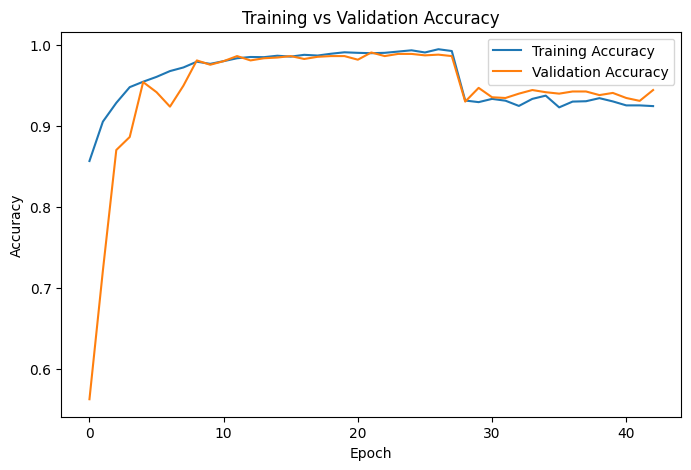

In [108]:
plt.figure(figsize=(8,5))

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

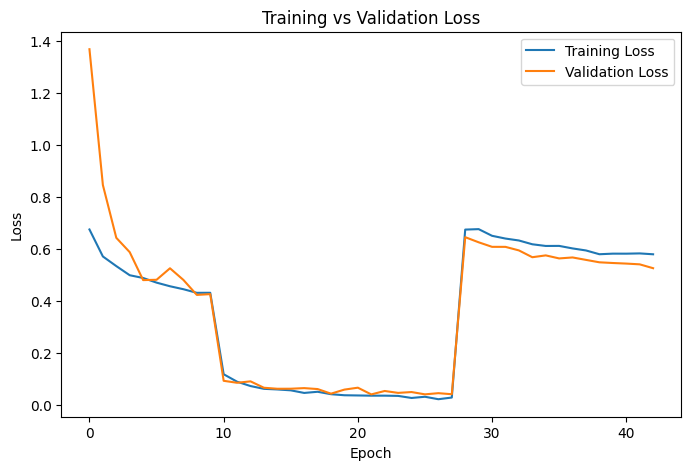

In [109]:
plt.figure(figsize=(8,5))

plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

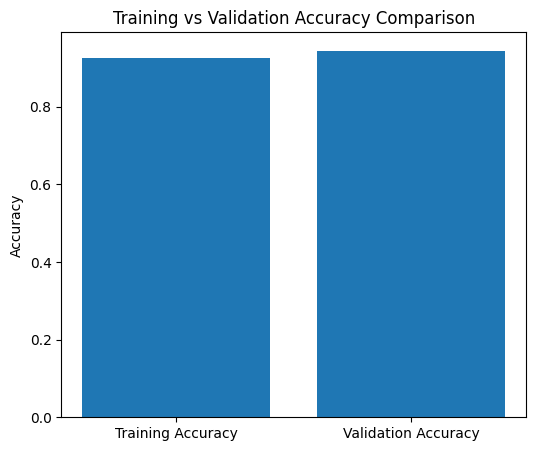

In [110]:
train_final = acc[-1]
val_final = val_acc[-1]

labels = ['Training Accuracy','Validation Accuracy']
values = [train_final, val_final]

plt.figure(figsize=(6,5))
plt.bar(labels, values)

plt.title('Training vs Validation Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

In [111]:
import numpy as np

predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step


In [112]:
import numpy as np

# 1. Get raw probability predictions from your trained model on the test set
# (Ensuring test_generator has shuffle=False, which you did in Cell 28)
y_pred_probs = model.predict(test_generator)
y_true = test_generator.classes

# 2. Define your class indices based on alphabetical flow_from_directory
GLIOMA_IDX = 0
MENINGIOMA_IDX = 1
NOTUMOR_IDX = 2
PITUITARY_IDX = 3

y_pred_adjusted = []

# 3. Apply the Clinical Safety Thresholds
for probs in y_pred_probs:
    # Catch the False Negatives: If there is even a 25% chance of Glioma, flag it.
    if probs[GLIOMA_IDX] > 0.25:
        y_pred_adjusted.append(GLIOMA_IDX)
    
    # Fix the Anatomical Mimicry: Give Meningioma priority over Pituitary at 35%
    elif probs[MENINGIOMA_IDX] > 0.35:
        y_pred_adjusted.append(MENINGIOMA_IDX)
        
    # Otherwise, fall back to the standard highest probability (argmax)
    else:
        y_pred_adjusted.append(np.argmax(probs))

y_pred_adjusted = np.array(y_pred_adjusted)

print("Clinical threshold calibration applied successfully.")

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step
Clinical threshold calibration applied successfully.


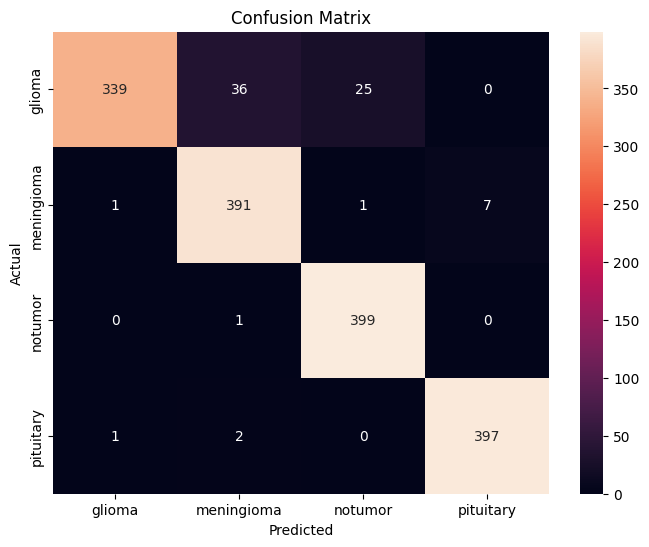

In [113]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# cm = confusion_matrix(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred_adjusted)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [114]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_labels))

              precision    recall  f1-score   support

      glioma       1.00      0.83      0.91       400
  meningioma       0.91      0.97      0.94       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



In [115]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Final Test Accuracy:", test_accuracy*100)
print("Final Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8942 - loss: 0.6445
Final Test Accuracy: 95.06250023841858
Final Test Loss: 0.4596061408519745


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step


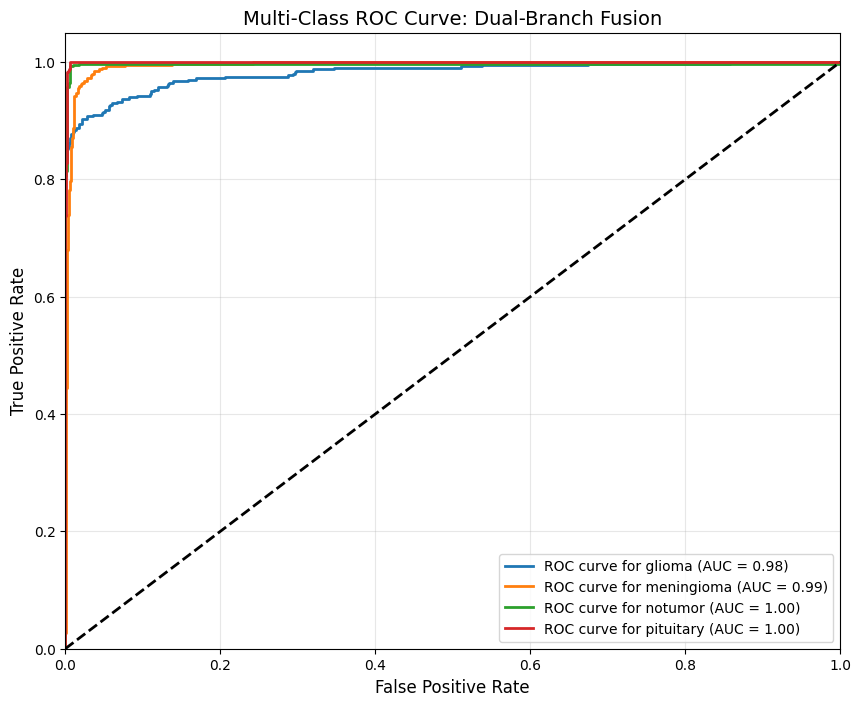

In [116]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Get true labels and predictions
# Ensure shuffle=False in your test_generator, which you correctly did!
y_true = test_generator.classes
y_pred = model.predict(test_generator)

# 2. Binarize the true labels for multi-class ROC
n_classes = len(class_labels)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# 3. Plot the ROC Curve
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve for {class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-Class ROC Curve: Dual-Branch Fusion', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [117]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_6[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 29,312,846 (111.82 MB)

 Trainable params: 9,760,260 (37.23 MB)

 Non-trainable params: 32,064 (125.25 KB)

 Optimizer params: 19,520,522 (74.46 MB)

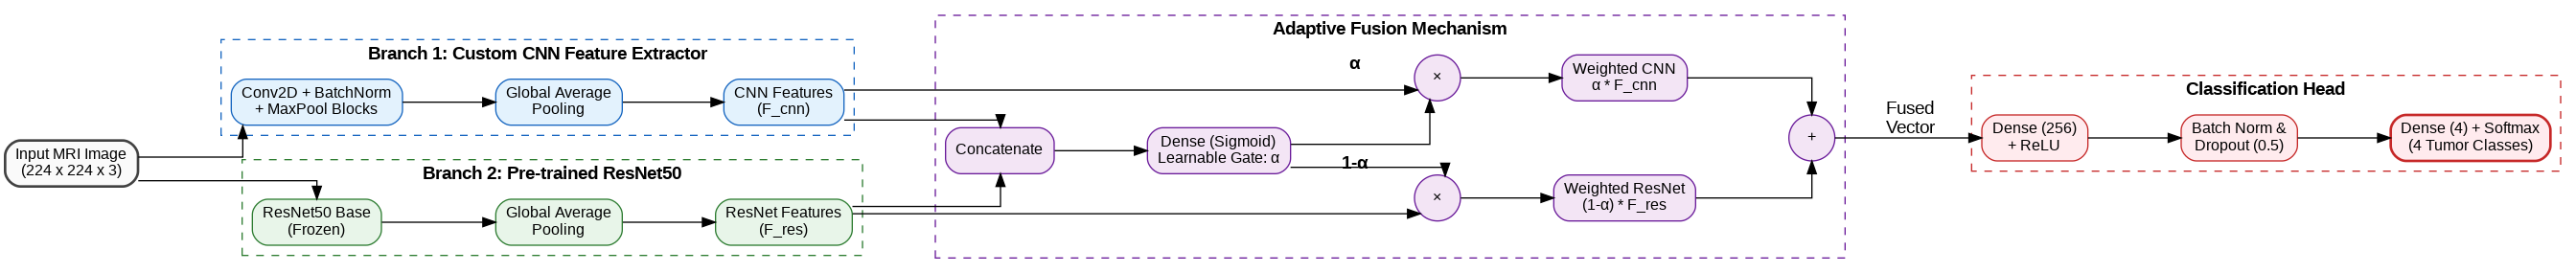

In [121]:
import graphviz
from IPython.display import Image

# Create the Graph
dot = graphviz.Digraph(comment='Dual-Branch Architecture', format='png')
dot.attr(rankdir='LR', splines='ortho', nodesep='0.8', ranksep='1.0')
dot.attr('node', fontname='Helvetica', fontsize='12', shape='box', style='filled, rounded')

# Input Node
dot.node('Input', 'Input MRI Image\n(224 x 224 x 3)', fillcolor='#fafafa', color='#424242', penwidth='2')

# Branch 1: Custom CNN
with dot.subgraph(name='cluster_cnn') as c:
    c.attr(label='Branch 1: Custom CNN Feature Extractor', style='dashed', color='#1565c0', fontname='Helvetica-Bold')
    c.node('CNN1', 'Conv2D + BatchNorm\n+ MaxPool Blocks', fillcolor='#e3f2fd', color='#1565c0')
    c.node('CNN2', 'Global Average\nPooling', fillcolor='#e3f2fd', color='#1565c0')
    c.node('F_cnn', 'CNN Features\n(F_cnn)', fillcolor='#e3f2fd', color='#1565c0')
    c.edge('CNN1', 'CNN2')
    c.edge('CNN2', 'F_cnn')

# Branch 2: ResNet50
with dot.subgraph(name='cluster_resnet') as c:
    c.attr(label='Branch 2: Pre-trained ResNet50', style='dashed', color='#2e7d32', fontname='Helvetica-Bold')
    c.node('RES1', 'ResNet50 Base\n(Frozen)', fillcolor='#e8f5e9', color='#2e7d32')
    c.node('RES2', 'Global Average\nPooling', fillcolor='#e8f5e9', color='#2e7d32')
    c.node('F_res', 'ResNet Features\n(F_res)', fillcolor='#e8f5e9', color='#2e7d32')
    c.edge('RES1', 'RES2')
    c.edge('RES2', 'F_res')

# Adaptive Fusion Mechanism
with dot.subgraph(name='cluster_fusion') as c:
    c.attr(label='Adaptive Fusion Mechanism', style='dashed', color='#6a1b9a', fontname='Helvetica-Bold')
    c.node('Concat', 'Concatenate', fillcolor='#f3e5f5', color='#6a1b9a')
    c.node('Alpha', 'Dense (Sigmoid)\nLearnable Gate: α', fillcolor='#f3e5f5', color='#6a1b9a')
    
    # Mathematical Multipliers
    c.node('Mult1', '×', shape='circle', fillcolor='#f3e5f5', color='#6a1b9a', width='0.5', fixedsize='true')
    c.node('Mult2', '×', shape='circle', fillcolor='#f3e5f5', color='#6a1b9a', width='0.5', fixedsize='true')
    
    c.node('W_CNN', 'Weighted CNN\nα * F_cnn', fillcolor='#f3e5f5', color='#6a1b9a')
    c.node('W_RES', 'Weighted ResNet\n(1-α) * F_res', fillcolor='#f3e5f5', color='#6a1b9a')
    
    c.node('Add', '+', shape='circle', fillcolor='#f3e5f5', color='#6a1b9a', width='0.5', fixedsize='true')

# Classification Head
with dot.subgraph(name='cluster_head') as c:
    c.attr(label='Classification Head', style='dashed', color='#c62828', fontname='Helvetica-Bold')
    c.node('D1', 'Dense (256)\n+ ReLU', fillcolor='#ffebee', color='#c62828')
    c.node('Drop', 'Batch Norm &\nDropout (0.5)', fillcolor='#ffebee', color='#c62828')
    c.node('Out', 'Dense (4) + Softmax\n(4 Tumor Classes)', fillcolor='#ffebee', color='#c62828', penwidth='2')
    c.edge('D1', 'Drop')
    c.edge('Drop', 'Out')

# Connect the main flow
dot.edge('Input', 'CNN1')
dot.edge('Input', 'RES1')

dot.edge('F_cnn', 'Concat')
dot.edge('F_res', 'Concat')

dot.edge('Concat', 'Alpha')

# The Multipliers
dot.edge('F_cnn', 'Mult1')
dot.edge('Alpha', 'Mult1', label=' α', fontname='Helvetica-Bold')
dot.edge('Mult1', 'W_CNN')

dot.edge('F_res', 'Mult2')
dot.edge('Alpha', 'Mult2', label=' 1-α', fontname='Helvetica-Bold')
dot.edge('Mult2', 'W_RES')

# The Addition
dot.edge('W_CNN', 'Add')
dot.edge('W_RES', 'Add')
dot.edge('Add', 'D1', label=' Fused\n Vector', fontname='Helvetica')

# Save and render the image in the Kaggle directory
output_path = '/kaggle/working/model_architecture'
dot.render(output_path, view=False, cleanup=True)

# Display in notebook
Image(filename=output_path + '.png')